In [1]:
import pandas as pd

In [2]:
df= pd.read_csv("Admission_Predict_Ver1.1.csv")

In [3]:
df.shape

(500, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop("Serial No.",axis=1,inplace=True)

In [7]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)


In [9]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
421,321,112,3,3.0,4.5,8.95,1
453,319,103,3,2.5,4.0,8.76,1
458,312,100,1,3.0,3.0,8.53,1
353,300,102,3,3.5,2.5,8.17,0
116,299,102,3,4.0,3.5,8.62,0
...,...,...,...,...,...,...,...
102,314,106,2,4.0,3.5,8.25,0
416,315,104,3,4.0,2.5,8.10,0
452,328,116,4,5.0,3.5,9.60,1
106,329,111,4,4.5,4.5,9.18,1


In [10]:
#We know the upper bound hence we'll use min max scaling

#We'll use the MinMaxScaler from sklearn


In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [12]:
import pickle as pkl
pkl.dump(scaler,open("scaler.pkl","wb"))

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [15]:
model = Sequential()
model.add(Dense(7,activation="relu",input_dim=7))
model.add(Dense(1,activation="linear"))

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(loss="mse",optimizer="adam")

In [18]:
history=model.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.6441 - val_loss: 0.5503
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4677 - val_loss: 0.4027
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3403 - val_loss: 0.2915
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2446 - val_loss: 0.2127
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1773 - val_loss: 0.1573
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1307 - val_loss: 0.1192
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0992 - val_loss: 0.0927
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0774 - val_loss: 0.0746
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0625 - val_loss: 0.0625
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0529 - val_loss: 0.0545
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0468 - val_loss: 0.0491
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 

In [19]:
y_pred=model.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


0.7951808088056296

In [20]:
model.save("model.h5")

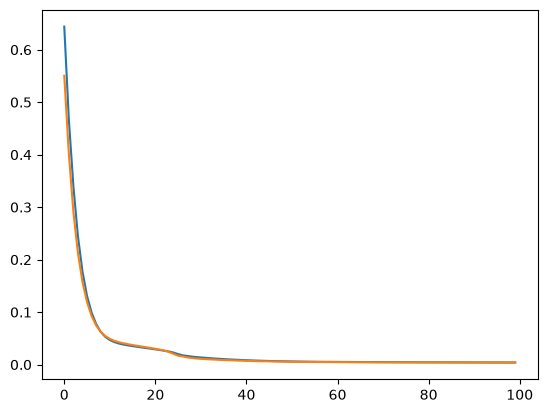

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()